### Импорт библиотек 

In [2]:
import pandas as pd
import numpy as np
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest
import matplotlib.pyplot as plt

### Загрузка данных

In [3]:
df = pd.read_csv('/Users/bavbeldiana463/Desktop/Диплом_курсы/Data_sql/ab_test_data.csv')
df

,user_id,max_step,group,finished_tutorial,sessions,events
0,1000001,4,B,0,1,9
1,1000004,0,A,0,1,1
2,1000006,7,A,1,1,14
3,1000007,1,B,0,1,3
4,1000008,7,A,1,1,14
...,...,...,...,...,...,...
516,1000975,5,B,0,1,11
517,1000977,7,B,1,1,14
518,1000980,3,A,0,1,7
519,1000983,1,B,0,1,3


In [23]:
# Инсайт - пользователи часто бросают игру на этапе тутора.

In [22]:
# Гипотеза
hyp = 'Новый упрощённый тутор увеличит процент завершения обучения.'

In [21]:
h0 = 'Новый тутор не приведет к увеличению процента завершения тутора.'
h1 = 'Новый тутор приведет к увеличению процента завершения тутора.'

In [4]:
print('Размер групп:')
print(df['group'].value_counts())
print(f"Всего пользователей: {len(df)}")

Размер групп:
group
A    270
B    251
Name: count, dtype: int64
Всего пользователей: 521


### Статистика

In [5]:
group_a = df[df['group'] == 'A']['finished_tutorial']
group_b = df[df['group'] == 'B']['finished_tutorial']

In [6]:
n_a = len(group_a)
n_b = len(group_b)
mean_a = group_a.mean()
mean_b = group_b.mean()
success_a = group_a.sum()
success_b = group_b.sum()

In [7]:
print('Конверсия:')
print(f"Группа A (старый): {mean_a:.2%} ({success_a}/{n_a})")
print(f"Группа B (новый):  {mean_b:.2%} ({success_b}/{n_b})")
print(f"Разница: {mean_b - mean_a:+.2%}")

Конверсия:
Группа A (старый): 40.74% (110/270)
Группа B (новый):  37.05% (93/251)
Разница: -3.69%


### Размер эффекта

In [8]:
pooled_std = np.sqrt(((n_a - 1) * group_a.var() + (n_b - 1) * group_b.var()) / (n_a + n_b - 2))
cohens_d = (mean_b - mean_a) / pooled_std
print(f"Размер эффекта: {cohens_d:.3f}")

Размер эффекта: -0.076


### Стат. тесты

# t-тест Уэлча (для неравных дисперсий)

In [9]:
t_stat, p_value_ttest = stats.ttest_ind(group_a, group_b, equal_var=False)
print(f"T-тест Уэлча")
print(f"t = {t_stat:.4f}, p = {p_value_ttest:.4f}")

T-тест Уэлча
t = 0.8622, p = 0.3890


# z-тест для пропорций

In [10]:
z_stat, p_value_ztest = proportions_ztest([success_a, success_b], [n_a, n_b])
print(f"Z-тест пропорций")
print(f"z = {z_stat:.4f}, p = {p_value_ztest:.4f}")

Z-тест пропорций
z = 0.8627, p = 0.3883


### Вывод

In [11]:
alpha = 0.05
p_value = p_value_ttest

print('Вывод:')
if p_value < alpha:
    print("Отвергаем H0: различия статистически значимы.")
    if mean_b > mean_a:
        print("Новый тутор лучше. Рекомендуется заменить.")
    else:
        print("Новый тутор хуже. Рекомендуется оставить старый.")
else:
    print("Не отвергаем H0: различия статистически не значимы.")
    print("Нет оснований утверждать, что новый тутор лучше.")

Вывод:
Не отвергаем H0: различия статистически не значимы.
Нет оснований утверждать, что новый тутор лучше.


### Визуализация 

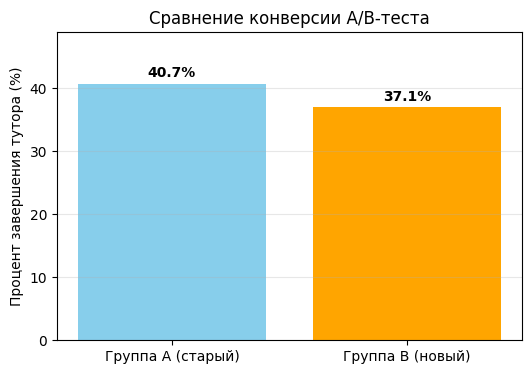

In [12]:
plt.figure(figsize=(6, 4))
bars = plt.bar(['Группа A (старый)', 'Группа B (новый)'],
               [mean_a * 100, mean_b * 100],
               color=['skyblue', 'orange'])
plt.ylabel('Процент завершения тутора (%)')
plt.title('Сравнение конверсии A/B-теста')
plt.ylim(0, max(mean_a, mean_b) * 100 * 1.2)
for bar, val in zip(bars, [mean_a * 100, mean_b * 100]):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{val:.1f}%', ha='center', fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.show()